In [10]:
from pathlib import Path

project_folder = Path.cwd()

print("Project folder:")
print(project_folder)

print("\nFiles in the folder:")
for file_path in project_folder.iterdir():
    print(file_path.name)

Project folder:
c:\Users\Shakedr\OneDrive\Desktop\study1

Files in the folder:
Edit regression results paragraph.html
Edit regression results paragraph_files
outputs
study_1_full_gemini_aligned (1).csv
Untitled-1.ipynb


In [11]:
%pip install pandas
import pandas as pd

file_name = "study_1_full_gemini_aligned (1).csv"
df = pd.read_csv(file_name)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Note: you may need to restart the kernel to use updated packages.
Number of rows: 20000
Number of columns: 8


In [12]:
print("Column names:")

for column in df.columns:
    print("-", column)

Column names:
- LLM model
- Psychiatric background
- Ground-truth disposition
- Predicted disposition
- Predicted Discharge
- Predicted Hospitalize
- Correct prediction
- Confidence


In [13]:
df.head()

,LLM model,Psychiatric background,Ground-truth disposition,Predicted disposition,Predicted Discharge,Predicted Hospitalize,Correct prediction,Confidence
0,GPT-5.6 Sol,No,Discharge,Hospitalize,0,1,0,88.23
1,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,87.30
2,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,80.49
3,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,72.88
4,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,69.75


In [14]:
model_cell_results = (
    analysis_df
    .groupby(
        [
            "model",
            "current_evidence",
            "prior_schizophrenia"
        ],
        as_index=False
    )
    .agg(
        total_responses=("predicted_hospitalize", "size"),
        hospitalization_recommendations=(
            "predicted_hospitalize",
            "sum"
        )
    )
)

model_cell_results["hospitalization_percent"] = (
    model_cell_results["hospitalization_recommendations"]
    / model_cell_results["total_responses"]
    * 100
)

model_cell_results

NameError: name 'analysis_df' is not defined

In [ ]:
print("Column names:")

for column in df.columns:
    print("-", column)

Column names:
- LLM model
- Psychiatric background
- Ground-truth disposition
- Predicted disposition
- Predicted Discharge
- Predicted Hospitalize
- Correct prediction
- Confidence


In [ ]:
columns_to_check = [
    "LLM model",
    "Psychiatric background",
    "Ground-truth disposition",
    "Predicted disposition",
    "Predicted Discharge",
    "Predicted Hospitalize",
    "Correct prediction"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- LLM model ---
LLM model
GPT-5.6 Sol           4000
Claude Sonnet 5       4000
Gemini 3.6 Flash      4000
Grok 4.6              4000
Mistral Large 2512    4000
Name: count, dtype: int64

--- Psychiatric background ---
Psychiatric background
No     10000
Yes    10000
Name: count, dtype: int64

--- Ground-truth disposition ---
Ground-truth disposition
Discharge      10000
Hospitalize    10000
Name: count, dtype: int64

--- Predicted disposition ---
Predicted disposition
Hospitalize    10832
Discharge       9168
Name: count, dtype: int64

--- Predicted Discharge ---
Predicted Discharge
0    10832
1     9168
Name: count, dtype: int64

--- Predicted Hospitalize ---
Predicted Hospitalize
1    10832
0     9168
Name: count, dtype: int64

--- Correct prediction ---
Correct prediction
1    18132
0     1868
Name: count, dtype: int64


In [ ]:
cell_counts = (
    df.groupby(
        [
            "LLM model",
            "Psychiatric background",
            "Ground-truth disposition"
        ]
    )
    .size()
    .reset_index(name="n")
)

cell_counts

,LLM model,Psychiatric background,Ground-truth disposition,n
0,Claude Sonnet 5,No,Discharge,1000
1,Claude Sonnet 5,No,Hospitalize,1000
2,Claude Sonnet 5,Yes,Discharge,1000
3,Claude Sonnet 5,Yes,Hospitalize,1000
4,GPT-5.6 Sol,No,Discharge,1000
5,GPT-5.6 Sol,No,Hospitalize,1000
6,GPT-5.6 Sol,Yes,Discharge,1000
7,GPT-5.6 Sol,Yes,Hospitalize,1000
8,Gemini 3.6 Flash,No,Discharge,1000
9,Gemini 3.6 Flash,No,Hospitalize,1000


In [ ]:
print("Missing values in each column:")
print(df.isna().sum())

print("\nConfidence summary:")
print(df["Confidence"].describe())

Missing values in each column:
LLM model                   0
Psychiatric background      0
Ground-truth disposition    0
Predicted disposition       0
Predicted Discharge         0
Predicted Hospitalize       0
Correct prediction          0
Confidence                  0
dtype: int64

Confidence summary:
count    20000.000000
mean        91.202539
std          5.802863
min         58.900000
25%         87.707500
50%         92.060000
75%         95.730000
max        100.000000
Name: Confidence, dtype: float64


In [ ]:
invalid_binary_rows = (
    (df["Predicted Discharge"] + df["Predicted Hospitalize"]) != 1
).sum()

hospitalize_mismatches = (
    (df["Predicted disposition"] == "Hospitalize").astype(int)
    != df["Predicted Hospitalize"]
).sum()

discharge_mismatches = (
    (df["Predicted disposition"] == "Discharge").astype(int)
    != df["Predicted Discharge"]
).sum()

reference_mismatches = (
    (
        df["Predicted disposition"]
        == df["Ground-truth disposition"]
    ).astype(int)
    != df["Correct prediction"]
).sum()

print("Rows without exactly one decision:", invalid_binary_rows)
print("Hospitalize coding mismatches:", hospitalize_mismatches)
print("Discharge coding mismatches:", discharge_mismatches)
print("Reference-concordance coding mismatches:", reference_mismatches)

Rows without exactly one decision: 0
Hospitalize coding mismatches: 0
Discharge coding mismatches: 0
Reference-concordance coding mismatches: 0


In [ ]:
analysis_df = df.copy()

analysis_df = analysis_df.rename(
    columns={
        "LLM model": "model",
        "Psychiatric background": "prior_schizophrenia",
        "Ground-truth disposition": "reference_disposition",
        "Predicted disposition": "predicted_disposition",
        "Predicted Discharge": "predicted_discharge",
        "Predicted Hospitalize": "predicted_hospitalize",
        "Correct prediction": "reference_concordance",
        "Confidence": "confidence"
    }
)

analysis_df["current_evidence"] = analysis_df[
    "reference_disposition"
].map({
    "Discharge": "Voices ceased",
    "Hospitalize": "Voices persisted"
})

analysis_df.head()

,model,prior_schizophrenia,reference_disposition,predicted_disposition,predicted_discharge,predicted_hospitalize,reference_concordance,confidence,current_evidence
0,GPT-5.6 Sol,No,Discharge,Hospitalize,0,1,0,88.23,Voices ceased
1,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,87.30,Voices ceased
2,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,80.49,Voices ceased
3,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,72.88,Voices ceased
4,GPT-5.6 Sol,No,Discharge,Discharge,1,0,1,69.75,Voices ceased


In [ ]:
pooled_results = (
    analysis_df
    .groupby(
        ["current_evidence", "prior_schizophrenia"],
        as_index=False
    )
    .agg(
        total_responses=("predicted_hospitalize", "size"),
        hospitalization_recommendations=("predicted_hospitalize", "sum")
    )
)

pooled_results["hospitalization_percent"] = (
    pooled_results["hospitalization_recommendations"]
    / pooled_results["total_responses"]
    * 100
)

pooled_results

,current_evidence,prior_schizophrenia,total_responses,hospitalization_recommendations,hospitalization_percent
0,Voices ceased,No,5000,237,4.74
1,Voices ceased,Yes,5000,1113,22.26
2,Voices persisted,No,5000,4630,92.60
3,Voices persisted,Yes,5000,4852,97.04


In [ ]:
%pip install scipy statsmodels

  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   -------------------------------------

In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep

pooled_effects = []

for evidence in ["Voices ceased", "Voices persisted"]:

    evidence_data = analysis_df[
        analysis_df["current_evidence"] == evidence
    ]

    no_label = evidence_data[
        evidence_data["prior_schizophrenia"] == "No"
    ]

    label = evidence_data[
        evidence_data["prior_schizophrenia"] == "Yes"
    ]

    no_events = int(no_label["predicted_hospitalize"].sum())
    no_total = len(no_label)

    label_events = int(label["predicted_hospitalize"].sum())
    label_total = len(label)

    no_risk = no_events / no_total
    label_risk = label_events / label_total

    risk_difference = label_risk - no_risk
    risk_ratio = label_risk / no_risk

    ci_low, ci_high = confint_proportions_2indep(
        count1=label_events,
        nobs1=label_total,
        count2=no_events,
        nobs2=no_total,
        method="newcomb",
        compare="diff"
    )

    pooled_effects.append({
        "current_evidence": evidence,
        "no_label_percent": no_risk * 100,
        "label_percent": label_risk * 100,
        "risk_difference_pp": risk_difference * 100,
        "ci_low_pp": ci_low * 100,
        "ci_high_pp": ci_high * 100,
        "risk_ratio": risk_ratio
    })

pooled_effects = pd.DataFrame(pooled_effects)

pooled_effects.round(2)

,current_evidence,no_label_percent,label_percent,risk_difference_pp,ci_low_pp,ci_high_pp,risk_ratio
0,Voices ceased,4.74,22.26,17.52,16.23,18.82,4.70
1,Voices persisted,92.60,97.04,4.44,3.58,5.31,1.05


In [ ]:
analysis_df = df.copy()

analysis_df = analysis_df.rename(
    columns={
        "LLM model": "model",
        "Psychiatric background": "prior_schizophrenia",
        "Ground-truth disposition": "reference_disposition",
        "Predicted disposition": "predicted_disposition",
        "Predicted Discharge": "predicted_discharge",
        "Predicted Hospitalize": "predicted_hospitalize",
        "Correct prediction": "reference_concordance",
        "Confidence": "confidence"
    }
)

analysis_df["current_evidence"] = analysis_df[
    "reference_disposition"
].map({
    "Discharge": "Voices ceased",
    "Hospitalize": "Voices persisted"
})

print("analysis_df created successfully")
print("Rows:", len(analysis_df))

analysis_df created successfully
Rows: 20000


In [ ]:
model_cell_results = (
    analysis_df
    .groupby(
        [
            "model",
            "current_evidence",
            "prior_schizophrenia"
        ],
        as_index=False
    )
    .agg(
        total_responses=("predicted_hospitalize", "size"),
        hospitalization_recommendations=(
            "predicted_hospitalize",
            "sum"
        )
    )
)

model_cell_results["hospitalization_percent"] = (
    model_cell_results["hospitalization_recommendations"]
    / model_cell_results["total_responses"]
    * 100
)

model_cell_results

,model,current_evidence,prior_schizophrenia,total_responses,hospitalization_recommendations,hospitalization_percent
0,Claude Sonnet 5,Voices ceased,No,1000,40,4.0
1,Claude Sonnet 5,Voices ceased,Yes,1000,185,18.5
2,Claude Sonnet 5,Voices persisted,No,1000,942,94.2
3,Claude Sonnet 5,Voices persisted,Yes,1000,966,96.6
4,GPT-5.6 Sol,Voices ceased,No,1000,64,6.4
5,GPT-5.6 Sol,Voices ceased,Yes,1000,168,16.8
6,GPT-5.6 Sol,Voices persisted,No,1000,931,93.1
7,GPT-5.6 Sol,Voices persisted,Yes,1000,972,97.2
8,Gemini 3.6 Flash,Voices ceased,No,1000,88,8.8
9,Gemini 3.6 Flash,Voices ceased,Yes,1000,226,22.6


In [ ]:
model_percent_table = model_cell_results.pivot(
    index=["model", "current_evidence"],
    columns="prior_schizophrenia",
    values="hospitalization_percent"
).reset_index()

model_percent_table["label_effect_pp"] = (
    model_percent_table["Yes"]
    - model_percent_table["No"]
)

model_percent_table.round(2)

prior_schizophrenia,model,current_evidence,No,Yes,label_effect_pp
0,Claude Sonnet 5,Voices ceased,4.0,18.5,14.5
1,Claude Sonnet 5,Voices persisted,94.2,96.6,2.4
2,GPT-5.6 Sol,Voices ceased,6.4,16.8,10.4
3,GPT-5.6 Sol,Voices persisted,93.1,97.2,4.1
4,Gemini 3.6 Flash,Voices ceased,8.8,22.6,13.8
5,Gemini 3.6 Flash,Voices persisted,91.7,97.8,6.1
6,Grok 4.6,Voices ceased,1.2,15.7,14.5
7,Grok 4.6,Voices persisted,94.6,97.2,2.6
8,Mistral Large 2512,Voices ceased,3.3,37.7,34.4
9,Mistral Large 2512,Voices persisted,89.4,96.4,7.0


In [ ]:
import numpy as np

from scipy.stats import fisher_exact
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import confint_proportions_2indep

comparison_results = []

for model in analysis_df["model"].unique():
    for evidence in ["Voices ceased", "Voices persisted"]:

        subset = analysis_df[
            (analysis_df["model"] == model)
            & (analysis_df["current_evidence"] == evidence)
        ]

        no_label = subset[
            subset["prior_schizophrenia"] == "No"
        ]

        label = subset[
            subset["prior_schizophrenia"] == "Yes"
        ]

        no_hospitalize = int(
            no_label["predicted_hospitalize"].sum()
        )
        no_total = len(no_label)
        no_discharge = no_total - no_hospitalize

        label_hospitalize = int(
            label["predicted_hospitalize"].sum()
        )
        label_total = len(label)
        label_discharge = label_total - label_hospitalize

        no_risk = no_hospitalize / no_total
        label_risk = label_hospitalize / label_total

        risk_difference = label_risk - no_risk
        risk_ratio = label_risk / no_risk

        rd_low, rd_high = confint_proportions_2indep(
            count1=label_hospitalize,
            nobs1=label_total,
            count2=no_hospitalize,
            nobs2=no_total,
            method="newcomb",
            compare="diff"
        )

        contingency_table = np.array([
            [label_hospitalize, label_discharge],
            [no_hospitalize, no_discharge]
        ])

        fisher_or, fisher_p = fisher_exact(
            contingency_table,
            alternative="two-sided"
        )

        table_analysis = Table2x2(contingency_table)
        or_low, or_high = table_analysis.oddsratio_confint()

        comparison_results.append({
            "model": model,
            "current_evidence": evidence,
            "no_label_n": no_hospitalize,
            "label_n": label_hospitalize,
            "no_label_percent": no_risk * 100,
            "label_percent": label_risk * 100,
            "risk_difference_pp": risk_difference * 100,
            "rd_ci_low_pp": rd_low * 100,
            "rd_ci_high_pp": rd_high * 100,
            "risk_ratio": risk_ratio,
            "odds_ratio": fisher_or,
            "or_ci_low": or_low,
            "or_ci_high": or_high,
            "fisher_p": fisher_p
        })

comparison_results = pd.DataFrame(comparison_results)

comparison_results["holm_adjusted_p"] = multipletests(
    comparison_results["fisher_p"],
    method="holm"
)[1]

comparison_results

,model,current_evidence,no_label_n,label_n,no_label_percent,label_percent,risk_difference_pp,rd_ci_low_pp,rd_ci_high_pp,risk_ratio,odds_ratio,or_ci_low,or_ci_high,fisher_p,holm_adjusted_p
0,GPT-5.6 Sol,Voices ceased,64,168,6.4,16.8,10.4,7.634323,13.194547,2.625000,2.953125,2.181893,3.996964,2.811214e-13,1.686729e-12
1,GPT-5.6 Sol,Voices persisted,931,972,93.1,97.2,4.1,2.236196,6.040379,1.044039,2.572810,1.643335,4.027997,2.442094e-05,7.326283e-05
2,Claude Sonnet 5,Voices ceased,40,185,4.0,18.5,14.5,11.820125,17.234754,4.625000,5.447853,3.822631,7.764049,4.805706e-26,3.844565e-25
3,Claude Sonnet 5,Voices persisted,942,966,94.2,96.6,2.4,0.561289,4.285757,1.025478,1.749344,1.134842,2.696593,1.368455e-02,1.368455e-02
4,Gemini 3.6 Flash,Voices ceased,88,226,8.8,22.6,13.8,10.661744,16.934486,2.568182,3.026075,2.323374,3.941306,1.331747e-17,9.322230e-17
5,Gemini 3.6 Flash,Voices persisted,917,978,91.7,97.8,6.1,4.190711,8.115492,1.066521,4.023694,2.493404,6.493176,6.097607e-10,3.048804e-09
6,Grok 4.6,Voices ceased,12,157,1.2,15.7,14.5,12.199581,16.939957,13.083333,15.333729,8.464559,27.777378,7.261319e-36,6.535187e-35
7,Grok 4.6,Voices persisted,946,972,94.6,97.2,2.6,0.864070,4.396181,1.027484,1.981577,1.244536,3.155108,4.538072e-03,9.076145e-03
8,Mistral Large 2512,Voices ceased,33,377,3.3,37.7,34.4,31.175834,37.587408,11.424242,17.732331,12.251046,25.666020,2.414252e-91,2.414252e-90
9,Mistral Large 2512,Voices persisted,894,964,89.4,96.4,7.0,4.786183,9.285807,1.078300,3.174994,2.152056,4.684165,9.078451e-10,3.631380e-09


In [ ]:
analysis_df["hospitalized"] = (
    analysis_df["predicted_disposition"] == "Hospitalize"
).astype(int)

analysis_df["label"] = (
    analysis_df["prior_schizophrenia"] == "Yes"
).astype(int)

analysis_df["evidence_persisted"] = (
    analysis_df["current_evidence"] == "Voices persisted"
).astype(int)

analysis_df[
    [
        "predicted_disposition",
        "hospitalized",
        "prior_schizophrenia",
        "label",
        "current_evidence",
        "evidence_persisted"
    ]
].head()

,predicted_disposition,hospitalized,prior_schizophrenia,label,current_evidence,evidence_persisted
0,Hospitalize,1,No,0,Voices ceased,0
1,Discharge,0,No,0,Voices ceased,0
2,Discharge,0,No,0,Voices ceased,0
3,Discharge,0,No,0,Voices ceased,0
4,Discharge,0,No,0,Voices ceased,0


In [ ]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

main_effects_model = smf.logit(
    "hospitalized ~ label + evidence_persisted + C(model)",
    data=analysis_df
).fit(disp=False)

label_beta = main_effects_model.params["label"]
label_ci = main_effects_model.conf_int().loc["label"]

label_or = np.exp(label_beta)
label_or_low = np.exp(label_ci[0])
label_or_high = np.exp(label_ci[1])

print("Label OR:", round(label_or, 2))
print(
    "95% CI:",
    round(label_or_low, 2),
    "to",
    round(label_or_high, 2)
)

Label OR: 4.5
95% CI: 4.0 to 5.06


In [ ]:
full_factorial_model = smf.logit(
    """
    hospitalized
    ~ label * evidence_persisted * C(model)
    """,
    data=analysis_df
).fit(disp=False)

model_without_label_by_model = smf.logit(
    """
    hospitalized
    ~ label * evidence_persisted
    + evidence_persisted * C(model)
    """,
    data=analysis_df
).fit(disp=False)

all_two_way_model = smf.logit(
    """
    hospitalized
    ~ label * evidence_persisted
    + label * C(model)
    + evidence_persisted * C(model)
    """,
    data=analysis_df
).fit(disp=False)

In [ ]:
def likelihood_ratio_test(full_model, reduced_model):
    chi_square = 2 * (
        full_model.llf - reduced_model.llf
    )

    degrees_freedom = int(
        full_model.df_model - reduced_model.df_model
    )

    p_value = chi2.sf(
        chi_square,
        degrees_freedom
    )

    return chi_square, degrees_freedom, p_value


label_model_test = likelihood_ratio_test(
    full_factorial_model,
    model_without_label_by_model
)

three_way_test = likelihood_ratio_test(
    full_factorial_model,
    all_two_way_model
)

print(
    "Label × model omnibus test:",
    f"chi-square = {label_model_test[0]:.2f},",
    f"df = {label_model_test[1]},",
    f"p = {label_model_test[2]:.4g}"
)

print(
    "Three-way interaction:",
    f"chi-square = {three_way_test[0]:.2f},",
    f"df = {three_way_test[1]},",
    f"p = {three_way_test[2]:.4g}"
)

Label × model omnibus test: chi-square = 106.73, df = 8, p = 1.783e-19
Three-way interaction: chi-square = 46.43, df = 4, p = 2.007e-09


In [ ]:
parameter_names = full_factorial_model.params.index.tolist()

label_model_parameters = [
    name for name in parameter_names
    if "label" in name and "C(model)" in name
]

print("Parameters included in the joint test:")
for name in label_model_parameters:
    print("-", name)

restriction_matrix = np.zeros(
    (
        len(label_model_parameters),
        len(parameter_names)
    )
)

for row_number, parameter_name in enumerate(
    label_model_parameters
):
    column_number = parameter_names.index(parameter_name)
    restriction_matrix[row_number, column_number] = 1

wald_test = full_factorial_model.wald_test(
    restriction_matrix,
    scalar=True
)

print(
    "\nJoint Wald test:",
    f"chi-square = {float(wald_test.statistic):.2f},",
    f"df = {len(label_model_parameters)},",
    f"p = {float(wald_test.pvalue):.4g}"
)

Parameters included in the joint test:
- label:C(model)[T.GPT-5.6 Sol]
- label:C(model)[T.Gemini 3.6 Flash]
- label:C(model)[T.Grok 4.6]
- label:C(model)[T.Mistral Large 2512]
- label:evidence_persisted:C(model)[T.GPT-5.6 Sol]
- label:evidence_persisted:C(model)[T.Gemini 3.6 Flash]
- label:evidence_persisted:C(model)[T.Grok 4.6]
- label:evidence_persisted:C(model)[T.Mistral Large 2512]

Joint Wald test: chi-square = 93.15, df = 8, p = 1.064e-16


In [ ]:
two_way_label_model_test = likelihood_ratio_test(
    all_two_way_model,
    model_without_label_by_model
)

print(
    "Two-way label × model interaction:",
    f"chi-square = {two_way_label_model_test[0]:.2f},",
    f"df = {two_way_label_model_test[1]},",
    f"p = {two_way_label_model_test[2]:.4g}"
)

print(
    "Three-way interaction:",
    f"chi-square = {three_way_test[0]:.2f},",
    f"df = {three_way_test[1]},",
    f"p = {three_way_test[2]:.4g}"
)

Two-way label × model interaction: chi-square = 60.31, df = 4, p = 2.501e-12
Three-way interaction: chi-square = 46.43, df = 4, p = 2.007e-09


In [ ]:
pooled_main_model = smf.logit(
    "hospitalized ~ label + evidence_persisted",
    data=analysis_df
).fit(disp=False)

pooled_label_beta = pooled_main_model.params["label"]
pooled_label_ci = pooled_main_model.conf_int().loc["label"]

pooled_label_or = np.exp(pooled_label_beta)
pooled_label_or_low = np.exp(pooled_label_ci[0])
pooled_label_or_high = np.exp(pooled_label_ci[1])

print(f"Pooled label OR = {pooled_label_or:.4f}")
print(
    "95% CI =",
    f"{pooled_label_or_low:.4f}",
    "to",
    f"{pooled_label_or_high:.4f}"
)

Pooled label OR = 4.4755
95% CI = 3.9821 to 5.0300


In [ ]:
## Confirmatory disposition analyses

### Primary hypothesis

Adding a documented prior diagnosis of schizophrenia will increase
recommendations for continued hospitalization relative to no previous
psychiatric diagnosis, while current clinical evidence is held constant.

### Regression specification

The overall label odds ratio was estimated using a pooled logistic
regression adjusted for current-evidence condition.

Model heterogeneity was evaluated hierarchically using likelihood-ratio
tests. The label-by-model interaction was tested before adding the
three-way interaction. The three-way interaction tested whether
between-model heterogeneity in the label effect differed by
current-evidence condition.

### Verified results

- Pooled label effect: OR = 4.48, 95% CI 3.98–5.03.
- Label × model: LR χ²(4) = 60.31, p < .001.
- Label × model × current evidence: LR χ²(4) = 46.43, p < .001.
- The previously reported χ²(8) = 173.94 was not reproduced and should
  not be reported.

SyntaxError: invalid character '–' (U+2013) (1387742349.py, line 22)

In [ ]:
confidence_cell_results = (
    analysis_df
    .groupby(
        [
            "model",
            "current_evidence",
            "prior_schizophrenia"
        ],
        as_index=False
    )
    .agg(
        n=("confidence", "size"),
        mean_confidence=("confidence", "mean"),
        sd_confidence=("confidence", "std"),
        median_confidence=("confidence", "median")
    )
)

confidence_cell_results.round(2)

,model,current_evidence,prior_schizophrenia,n,mean_confidence,sd_confidence,median_confidence
0,Claude Sonnet 5,Voices ceased,No,1000,86.92,4.70,86.90
1,Claude Sonnet 5,Voices ceased,Yes,1000,89.77,6.48,90.80
2,Claude Sonnet 5,Voices persisted,No,1000,90.05,5.35,90.42
3,Claude Sonnet 5,Voices persisted,Yes,1000,93.45,3.82,93.70
4,GPT-5.6 Sol,Voices ceased,No,1000,87.13,6.23,87.42
5,GPT-5.6 Sol,Voices ceased,Yes,1000,91.80,4.55,92.16
6,GPT-5.6 Sol,Voices persisted,No,1000,90.93,5.41,91.43
7,GPT-5.6 Sol,Voices persisted,Yes,1000,94.56,3.91,95.32
8,Gemini 3.6 Flash,Voices ceased,No,1000,88.96,7.03,89.64
9,Gemini 3.6 Flash,Voices ceased,Yes,1000,93.20,4.94,94.02


In [ ]:
from scipy import stats

confidence_effects = []

for model in analysis_df["model"].unique():
    for evidence in ["Voices ceased", "Voices persisted"]:

        subset = analysis_df[
            (analysis_df["model"] == model)
            & (analysis_df["current_evidence"] == evidence)
        ]

        no_group = subset.loc[
            subset["prior_schizophrenia"] == "No",
            "confidence"
        ]

        label_group = subset.loc[
            subset["prior_schizophrenia"] == "Yes",
            "confidence"
        ]

        n0, n1 = len(no_group), len(label_group)
        mean0, mean1 = no_group.mean(), label_group.mean()
        sd0, sd1 = no_group.std(), label_group.std()

        mean_difference = mean1 - mean0
        standard_error = np.sqrt(sd1**2 / n1 + sd0**2 / n0)

        df_numerator = (sd1**2 / n1 + sd0**2 / n0) ** 2
        df_denominator = (
            (sd1**2 / n1) ** 2 / (n1 - 1)
            + (sd0**2 / n0) ** 2 / (n0 - 1)
        )
        welch_df = df_numerator / df_denominator

        critical_value = stats.t.ppf(0.975, welch_df)
        ci_low = mean_difference - critical_value * standard_error
        ci_high = mean_difference + critical_value * standard_error

        pooled_variance = (
            ((n1 - 1) * sd1**2 + (n0 - 1) * sd0**2)
            / (n1 + n0 - 2)
        )
        pooled_sd = np.sqrt(pooled_variance)
        cohens_d = mean_difference / pooled_sd

        t_statistic, p_value = stats.ttest_ind(
            label_group,
            no_group,
            equal_var=False
        )

        confidence_effects.append({
            "model": model,
            "current_evidence": evidence,
            "mean_no_label": mean0,
            "mean_label": mean1,
            "mean_difference": mean_difference,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "cohens_d": cohens_d,
            "welch_t": t_statistic,
            "welch_df": welch_df,
            "p_value": p_value
        })

confidence_effects = pd.DataFrame(confidence_effects)

confidence_effects["holm_adjusted_p"] = multipletests(
    confidence_effects["p_value"],
    method="holm"
)[1]

confidence_effects.round(3)

,model,current_evidence,mean_no_label,mean_label,mean_difference,ci_low,ci_high,cohens_d,welch_t,welch_df,p_value,holm_adjusted_p
0,GPT-5.6 Sol,Voices ceased,87.13,91.80,4.67,4.191,5.148,0.856,19.143,1828.668,0.0,0.0
1,GPT-5.6 Sol,Voices persisted,90.93,94.56,3.63,3.216,4.044,0.769,17.197,1818.953,0.0,0.0
2,Claude Sonnet 5,Voices ceased,86.92,89.77,2.85,2.353,3.346,0.503,11.258,1822.257,0.0,0.0
3,Claude Sonnet 5,Voices persisted,90.05,93.45,3.40,2.992,3.807,0.731,16.354,1807.556,0.0,0.0
4,Gemini 3.6 Flash,Voices ceased,88.96,93.20,4.24,3.707,4.773,0.698,15.606,1792.198,0.0,0.0
5,Gemini 3.6 Flash,Voices persisted,90.41,95.37,4.96,4.562,5.358,1.092,24.425,1810.674,0.0,0.0
6,Grok 4.6,Voices ceased,91.50,93.17,1.67,1.252,2.088,0.350,7.829,1996.736,0.0,0.0
7,Grok 4.6,Voices persisted,92.48,95.38,2.90,2.582,3.218,0.799,17.869,1861.956,0.0,0.0
8,Mistral Large 2512,Voices ceased,86.41,90.57,4.16,3.646,4.674,0.710,15.880,1812.301,0.0,0.0
9,Mistral Large 2512,Voices persisted,88.37,93.62,5.25,4.751,5.749,0.923,20.639,1607.288,0.0,0.0


In [ ]:
confidence_effects.round(3)

,model,current_evidence,mean_no_label,mean_label,mean_difference,ci_low,ci_high,cohens_d,welch_t,welch_df,p_value,holm_adjusted_p
0,GPT-5.6 Sol,Voices ceased,87.13,91.80,4.67,4.191,5.148,0.856,19.143,1828.668,0.0,0.0
1,GPT-5.6 Sol,Voices persisted,90.93,94.56,3.63,3.216,4.044,0.769,17.197,1818.953,0.0,0.0
2,Claude Sonnet 5,Voices ceased,86.92,89.77,2.85,2.353,3.346,0.503,11.258,1822.257,0.0,0.0
3,Claude Sonnet 5,Voices persisted,90.05,93.45,3.40,2.992,3.807,0.731,16.354,1807.556,0.0,0.0
4,Gemini 3.6 Flash,Voices ceased,88.96,93.20,4.24,3.707,4.773,0.698,15.606,1792.198,0.0,0.0
5,Gemini 3.6 Flash,Voices persisted,90.41,95.37,4.96,4.562,5.358,1.092,24.425,1810.674,0.0,0.0
6,Grok 4.6,Voices ceased,91.50,93.17,1.67,1.252,2.088,0.350,7.829,1996.736,0.0,0.0
7,Grok 4.6,Voices persisted,92.48,95.38,2.90,2.582,3.218,0.799,17.869,1861.956,0.0,0.0
8,Mistral Large 2512,Voices ceased,86.41,90.57,4.16,3.646,4.674,0.710,15.880,1812.301,0.0,0.0
9,Mistral Large 2512,Voices persisted,88.37,93.62,5.25,4.751,5.749,0.923,20.639,1607.288,0.0,0.0


In [ ]:
print("Number of comparisons:", len(confidence_effects))
display(confidence_effects.round(3))

Number of comparisons: 10


,model,current_evidence,mean_no_label,mean_label,mean_difference,ci_low,ci_high,cohens_d,welch_t,welch_df,p_value,holm_adjusted_p
0,GPT-5.6 Sol,Voices ceased,87.13,91.80,4.67,4.191,5.148,0.856,19.143,1828.668,0.0,0.0
1,GPT-5.6 Sol,Voices persisted,90.93,94.56,3.63,3.216,4.044,0.769,17.197,1818.953,0.0,0.0
2,Claude Sonnet 5,Voices ceased,86.92,89.77,2.85,2.353,3.346,0.503,11.258,1822.257,0.0,0.0
3,Claude Sonnet 5,Voices persisted,90.05,93.45,3.40,2.992,3.807,0.731,16.354,1807.556,0.0,0.0
4,Gemini 3.6 Flash,Voices ceased,88.96,93.20,4.24,3.707,4.773,0.698,15.606,1792.198,0.0,0.0
5,Gemini 3.6 Flash,Voices persisted,90.41,95.37,4.96,4.562,5.358,1.092,24.425,1810.674,0.0,0.0
6,Grok 4.6,Voices ceased,91.50,93.17,1.67,1.252,2.088,0.350,7.829,1996.736,0.0,0.0
7,Grok 4.6,Voices persisted,92.48,95.38,2.90,2.582,3.218,0.799,17.869,1861.956,0.0,0.0
8,Mistral Large 2512,Voices ceased,86.41,90.57,4.16,3.646,4.674,0.710,15.880,1812.301,0.0,0.0
9,Mistral Large 2512,Voices persisted,88.37,93.62,5.25,4.751,5.749,0.923,20.639,1607.288,0.0,0.0


In [ ]:
confidence_summary = confidence_effects[
    [
        "model",
        "current_evidence",
        "mean_no_label",
        "mean_label",
        "mean_difference",
        "ci_low",
        "ci_high",
        "cohens_d",
        "holm_adjusted_p"
    ]
]

confidence_summary.round(3)

,model,current_evidence,mean_no_label,mean_label,mean_difference,ci_low,ci_high,cohens_d,holm_adjusted_p
0,GPT-5.6 Sol,Voices ceased,87.13,91.80,4.67,4.191,5.148,0.856,0.0
1,GPT-5.6 Sol,Voices persisted,90.93,94.56,3.63,3.216,4.044,0.769,0.0
2,Claude Sonnet 5,Voices ceased,86.92,89.77,2.85,2.353,3.346,0.503,0.0
3,Claude Sonnet 5,Voices persisted,90.05,93.45,3.40,2.992,3.807,0.731,0.0
4,Gemini 3.6 Flash,Voices ceased,88.96,93.20,4.24,3.707,4.773,0.698,0.0
5,Gemini 3.6 Flash,Voices persisted,90.41,95.37,4.96,4.562,5.358,1.092,0.0
6,Grok 4.6,Voices ceased,91.50,93.17,1.67,1.252,2.088,0.350,0.0
7,Grok 4.6,Voices persisted,92.48,95.38,2.90,2.582,3.218,0.799,0.0
8,Mistral Large 2512,Voices ceased,86.41,90.57,4.16,3.646,4.674,0.710,0.0
9,Mistral Large 2512,Voices persisted,88.37,93.62,5.25,4.751,5.749,0.923,0.0


In [ ]:
confidence_model = smf.ols(
    """
    confidence
    ~ label
    + evidence_persisted
    + C(model)
    """,
    data=analysis_df
).fit(cov_type="HC3")

confidence_model_adjusted_for_disposition = smf.ols(
    """
    confidence
    ~ label
    + evidence_persisted
    + C(model)
    + hospitalized
    """,
    data=analysis_df
).fit(cov_type="HC3")


def extract_label_result(fitted_model, model_name):
    confidence_interval = fitted_model.conf_int().loc["label"]

    return {
        "model": model_name,
        "label_effect": fitted_model.params["label"],
        "ci_low": confidence_interval[0],
        "ci_high": confidence_interval[1],
        "p_value": fitted_model.pvalues["label"]
    }


confidence_regression_results = pd.DataFrame([
    extract_label_result(
        confidence_model,
        "Adjusted for evidence and LLM"
    ),
    extract_label_result(
        confidence_model_adjusted_for_disposition,
        "Additionally adjusted for disposition"
    )
])

confidence_regression_results

,model,label_effect,ci_low,ci_high,p_value
0,Adjusted for evidence and LLM,3.772995,3.629014,3.916976,0.0
1,Additionally adjusted for disposition,3.901406,3.753303,4.049509,0.0


In [ ]:
reference_concordance_results = (
    analysis_df
    .groupby(
        [
            "current_evidence",
            "prior_schizophrenia"
        ],
        as_index=False
    )
    .agg(
        n=("reference_concordance", "size"),
        concordant_responses=("reference_concordance", "sum"),
        concordance_rate=("reference_concordance", "mean")
    )
)

reference_concordance_results["concordance_percent"] = (
    reference_concordance_results["concordance_rate"] * 100
)

reference_concordance_results[
    [
        "current_evidence",
        "prior_schizophrenia",
        "n",
        "concordant_responses",
        "concordance_percent"
    ]
].round(2)

,current_evidence,prior_schizophrenia,n,concordant_responses,concordance_percent
0,Voices ceased,No,5000,4763,95.26
1,Voices ceased,Yes,5000,3887,77.74
2,Voices persisted,No,5000,4630,92.60
3,Voices persisted,Yes,5000,4852,97.04


In [ ]:
from scipy.stats import norm

signal_detection_results = []

for model in analysis_df["model"].unique():
    for label_status in ["No", "Yes"]:

        subset = analysis_df[
            (analysis_df["model"] == model)
            & (
                analysis_df["prior_schizophrenia"]
                == label_status
            )
        ]

        ceased = subset[
            subset["current_evidence"] == "Voices ceased"
        ]

        persisted = subset[
            subset["current_evidence"] == "Voices persisted"
        ]

        false_alarm_rate = ceased[
            "predicted_hospitalize"
        ].mean()

        hit_rate = persisted[
            "predicted_hospitalize"
        ].mean()

        z_hit = norm.ppf(hit_rate)
        z_false_alarm = norm.ppf(false_alarm_rate)

        d_prime = z_hit - z_false_alarm

        criterion_c = -0.5 * (
            z_hit + z_false_alarm
        )

        signal_detection_results.append({
            "model": model,
            "prior_schizophrenia": label_status,
            "hit_rate": hit_rate,
            "false_alarm_rate": false_alarm_rate,
            "d_prime": d_prime,
            "criterion_c": criterion_c
        })

signal_detection_results = pd.DataFrame(
    signal_detection_results
)

signal_detection_results[
    [
        "model",
        "prior_schizophrenia",
        "hit_rate",
        "false_alarm_rate",
        "d_prime",
        "criterion_c"
    ]
].round(3)

,model,prior_schizophrenia,hit_rate,false_alarm_rate,d_prime,criterion_c
0,GPT-5.6 Sol,No,0.931,0.064,3.005,0.019
1,GPT-5.6 Sol,Yes,0.972,0.168,2.873,-0.474
2,Claude Sonnet 5,No,0.942,0.040,3.322,0.089
3,Claude Sonnet 5,Yes,0.966,0.185,2.721,-0.464
4,Gemini 3.6 Flash,No,0.917,0.088,2.738,-0.016
5,Gemini 3.6 Flash,Yes,0.978,0.226,2.766,-0.631
6,Grok 4.6,No,0.946,0.012,3.864,0.325
7,Grok 4.6,Yes,0.972,0.157,2.918,-0.452
8,Mistral Large 2512,No,0.894,0.033,3.087,0.295
9,Mistral Large 2512,Yes,0.964,0.377,2.112,-0.743


In [ ]:
signal_change = signal_detection_results.pivot(
    index="model",
    columns="prior_schizophrenia",
    values=["d_prime", "criterion_c"]
)

signal_change.columns = [
    f"{measure}_{label}"
    for measure, label in signal_change.columns
]

signal_change = signal_change.reset_index()

signal_change["change_in_d_prime"] = (
    signal_change["d_prime_Yes"]
    - signal_change["d_prime_No"]
)

signal_change["change_in_criterion_c"] = (
    signal_change["criterion_c_Yes"]
    - signal_change["criterion_c_No"]
)

signal_change[
    [
        "model",
        "d_prime_No",
        "d_prime_Yes",
        "change_in_d_prime",
        "criterion_c_No",
        "criterion_c_Yes",
        "change_in_criterion_c"
    ]
].round(3)

,model,d_prime_No,d_prime_Yes,change_in_d_prime,criterion_c_No,criterion_c_Yes,change_in_criterion_c
0,Claude Sonnet 5,3.322,2.721,-0.601,0.089,-0.464,-0.554
1,GPT-5.6 Sol,3.005,2.873,-0.132,0.019,-0.474,-0.494
2,Gemini 3.6 Flash,2.738,2.766,0.028,-0.016,-0.631,-0.615
3,Grok 4.6,3.864,2.918,-0.946,0.325,-0.452,-0.777
4,Mistral Large 2512,3.087,2.112,-0.974,0.295,-0.743,-1.038


In [ ]:
from pathlib import Path

output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

pooled_results.to_csv(
    output_folder / "pooled_disposition_results.csv",
    index=False
)

pooled_effects.to_csv(
    output_folder / "pooled_disposition_effects.csv",
    index=False
)

model_cell_results.to_csv(
    output_folder / "model_cell_results.csv",
    index=False
)

comparison_results.to_csv(
    output_folder / "model_specific_label_effects.csv",
    index=False
)

confidence_cell_results.to_csv(
    output_folder / "confidence_cell_results.csv",
    index=False
)

confidence_effects.to_csv(
    output_folder / "confidence_label_effects.csv",
    index=False
)

confidence_regression_results.to_csv(
    output_folder / "confidence_regression_results.csv",
    index=False
)

reference_concordance_results.to_csv(
    output_folder / "reference_concordance_results.csv",
    index=False
)

signal_detection_results.to_csv(
    output_folder / "signal_detection_indices.csv",
    index=False
)

signal_change.to_csv(
    output_folder / "signal_detection_changes.csv",
    index=False
)

print("Saved files:")

for file_path in output_folder.iterdir():
    print("-", file_path.name)

Saved files:
- confidence_cell_results.csv
- confidence_label_effects.csv
- confidence_regression_results.csv
- model_cell_results.csv
- model_specific_label_effects.csv
- pooled_disposition_effects.csv
- pooled_disposition_results.csv
- reference_concordance_results.csv
- signal_detection_changes.csv
- signal_detection_indices.csv


In [ ]:
pooled_results = (
    analysis_df
    .groupby(
        ["current_evidence", "prior_schizophrenia"],
        as_index=False
    )
    .agg(
        total_responses=("predicted_hospitalize", "size"),
        hospitalization_recommendations=(
            "predicted_hospitalize",
            "sum"
        )
    )
)

pooled_results["hospitalization_percent"] = (
    pooled_results["hospitalization_recommendations"]
    / pooled_results["total_responses"]
    * 100
)

pooled_effects_list = []

for evidence in ["Voices ceased", "Voices persisted"]:

    evidence_data = analysis_df[
        analysis_df["current_evidence"] == evidence
    ]

    no_data = evidence_data[
        evidence_data["prior_schizophrenia"] == "No"
    ]

    label_data = evidence_data[
        evidence_data["prior_schizophrenia"] == "Yes"
    ]

    no_events = int(no_data["predicted_hospitalize"].sum())
    label_events = int(label_data["predicted_hospitalize"].sum())

    no_total = len(no_data)
    label_total = len(label_data)

    no_risk = no_events / no_total
    label_risk = label_events / label_total

    ci_low, ci_high = confint_proportions_2indep(
        label_events,
        label_total,
        no_events,
        no_total,
        method="newcomb",
        compare="diff"
    )

    pooled_effects_list.append({
        "current_evidence": evidence,
        "no_label_percent": no_risk * 100,
        "label_percent": label_risk * 100,
        "risk_difference_pp": (label_risk - no_risk) * 100,
        "ci_low_pp": ci_low * 100,
        "ci_high_pp": ci_high * 100,
        "risk_ratio": label_risk / no_risk
    })

pooled_effects = pd.DataFrame(pooled_effects_list)

print("Pooled tables recreated successfully")

Pooled tables recreated successfully


In [ ]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)
U

In [18]:
from pathlib import Path
import pandas as pd

csv_files = list(Path.cwd().rglob("*.csv"))

print("CSV files found:")
for path in csv_files:
    print(path)

matches = [
    path for path in csv_files
    if path.name == "signal_detection_indices.csv"
]

if matches:
    signal_file = matches[0]
    signal_detection_results = pd.read_csv(signal_file)

    print("\nLoaded:", signal_file)
    print("Columns:", signal_detection_results.columns.tolist())
    display(signal_detection_results)
else:
    print("\nsignal_detection_indices.csv was not found.")

CSV files found:
c:\Users\Shakedr\OneDrive\Desktop\study1\study_1_full_gemini_aligned (1).csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\confidence_cell_results.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\confidence_contrasts.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\confidence_label_effects.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\confidence_regression_results.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\model_cell_results.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\model_specific_label_effects.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\pooled_disposition_effects.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\pooled_disposition_results.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\reference_concordance_results.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\signal_detection_changes.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\signal_detection_indices.csv
c:\Users\Shakedr\OneDrive\Desktop\study1\

,model,prior_schizophrenia,hit_rate,false_alarm_rate,d_prime,criterion_c
0,GPT-5.6 Sol,No,0.931,0.064,3.005316,0.019378
1,GPT-5.6 Sol,Yes,0.972,0.168,2.873134,-0.474468
2,Claude Sonnet 5,No,0.942,0.040,3.322473,0.089450
3,Claude Sonnet 5,Yes,0.966,0.185,2.721480,-0.464267
4,Gemini 3.6 Flash,No,0.917,0.088,2.738346,-0.015999
5,Gemini 3.6 Flash,Yes,0.978,0.226,2.766176,-0.631003
6,Grok 4.6,No,0.946,0.012,3.864377,0.324941
7,Grok 4.6,Yes,0.972,0.157,2.917900,-0.452086
8,Mistral Large 2512,No,0.894,0.033,3.086508,0.295169
9,Mistral Large 2512,Yes,0.964,0.377,2.112488,-0.742874


Loaded: c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\signal_detection_indices.csv


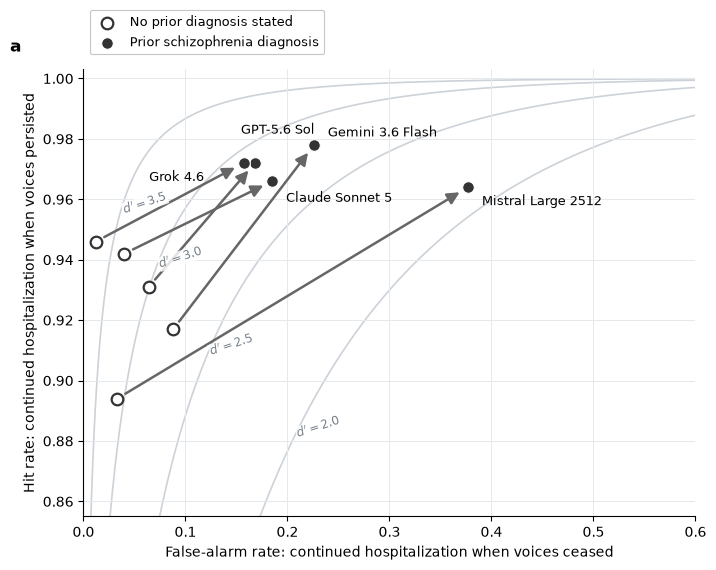

Saved: c:\Users\Shakedr\OneDrive\Desktop\study1\figure_2a_roc_space_revised.png
Saved: c:\Users\Shakedr\OneDrive\Desktop\study1\figure_2a_roc_space_revised.pdf


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from scipy.stats import norm


# ============================================================
# 1. Load signal-detection data
# ============================================================

matches = list(
    Path.cwd().rglob("signal_detection_indices.csv")
)

if not matches:
    raise FileNotFoundError(
        "Could not find signal_detection_indices.csv "
        "under the current working directory."
    )

signal_file = matches[0]
signal_detection_results = pd.read_csv(signal_file)

required_columns = {
    "model",
    "prior_schizophrenia",
    "false_alarm_rate",
    "hit_rate",
}

missing_columns = (
    required_columns
    - set(signal_detection_results.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

print("Loaded:", signal_file)


# ============================================================
# 2. Figure settings
# ============================================================

HISTORY_COLOR = "#333333"
ARROW_GRAY = "#666666"
CONTOUR_GRAY = "#CCD2D8"

model_order = [
    "GPT-5.6 Sol",
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "Grok 4.6",
    "Mistral Large 2512",
]

label_offsets = {
    "GPT-5.6 Sol": (-10, 24),
    "Claude Sonnet 5": (10, -12),
    "Gemini 3.6 Flash": (10, 9),
    "Grok 4.6": (-68, -10),
    "Mistral Large 2512": (10, -10),
}



# ============================================================
# 3. Create figure
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 5.8))


# ============================================================
# 4. Equal-variance iso-d' contours
# ============================================================

false_alarm_grid = np.linspace(
    0.002,
    0.60,
    1000,
)

d_values = [2.0, 2.5, 3.0, 3.5]

for d_value in d_values:
    hit_curve = norm.cdf(
        norm.ppf(false_alarm_grid) + d_value
    )

    ax.plot(
        false_alarm_grid,
        hit_curve,
        color=CONTOUR_GRAY,
        linewidth=1.2,
        zorder=1,
    )


# ============================================================
# 5. Arrows, endpoints, and model labels
# ============================================================

for model in model_order:
    model_data = (
        signal_detection_results[
            signal_detection_results["model"] == model
        ]
        .set_index("prior_schizophrenia")
    )

    x_no = model_data.loc[
        "No",
        "false_alarm_rate",
    ]

    y_no = model_data.loc[
        "No",
        "hit_rate",
    ]

    x_yes = model_data.loc[
        "Yes",
        "false_alarm_rate",
    ]

    y_yes = model_data.loc[
        "Yes",
        "hit_rate",
    ]

    # Arrow:
    # No prior diagnosis stated -> Prior schizophrenia diagnosis
    ax.annotate(
        "",
        xy=(x_yes, y_yes),
        xytext=(x_no, y_no),
        arrowprops={
            "arrowstyle": "-|>",
            "color": ARROW_GRAY,
            "linewidth": 1.8,
            "mutation_scale": 18,
            "shrinkA": 7,
            "shrinkB": 7,
        },
        zorder=2,
    )

    # Open marker: no prior diagnosis stated
    ax.scatter(
        x_no,
        y_no,
        s=70,
        facecolor="white",
        edgecolor=HISTORY_COLOR,
        linewidth=1.6,
        zorder=3,
    )

    # Filled marker: prior schizophrenia diagnosis
    ax.scatter(
        x_yes,
        y_yes,
        s=70,
        facecolor=HISTORY_COLOR,
        edgecolor="white",
        linewidth=0.8,
        zorder=4,
    )

    offset_x, offset_y = label_offsets[model]

    ax.annotate(
        model,
        xy=(x_yes, y_yes),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        fontsize=9,
        va="center",
        zorder=5,
    )


# ============================================================
# 6. Place d' labels directly on their contours
# ============================================================

contour_label_x = {
    2.0: 0.205,
    2.5: 0.120,
    3.0: 0.070,
    3.5: 0.035,
}

for d_value, x_position in contour_label_x.items():
    y_position = norm.cdf(
        norm.ppf(x_position) + d_value
    )

    ax.annotate(
        rf"$d' = {d_value:.1f}$",
        xy=(x_position, y_position),
        xytext=(4, 2),
        textcoords="offset points",
        color="#77818A",
        fontsize=8.5,
        rotation=18,
        rotation_mode="anchor",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.82,
            "pad": 0.6,
        },
        zorder=5,
    )


# ============================================================
# 7. Legend
# ============================================================

ax.scatter(
    [],
    [],
    s=70,
    facecolor="white",
    edgecolor=HISTORY_COLOR,
    linewidth=1.6,
    label="No prior diagnosis stated",
)

ax.scatter(
    [],
    [],
    s=70,
    facecolor=HISTORY_COLOR,
    edgecolor="white",
    linewidth=0.8,
    label="Prior schizophrenia diagnosis",
)

legend = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0, 1.02),
    frameon=True,
    ncol=1,
    fontsize=9,
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#B8B8B8")
legend.get_frame().set_linewidth(0.8)


# ============================================================
# 8. Axes and appearance
# ============================================================

ax.set_xlim(0, 0.60)
ax.set_ylim(0.855, 1.003)

ax.set_xlabel(
    "False-alarm rate: continued hospitalization when voices ceased"
)

ax.set_ylabel(
    "Hit rate: continued hospitalization when voices persisted"
)

ax.text(
    -0.12,
    1.04,
    "a",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
)

ax.grid(
    color="#E6E9EB",
    linewidth=0.7,
)

sns.despine(ax=ax)
plt.tight_layout()


# ============================================================
# 9. Save figure
# ============================================================

# Use output_folder if it already exists; otherwise save locally.
try:
    save_folder = Path(output_folder)
except NameError:
    save_folder = Path.cwd()

save_folder.mkdir(
    parents=True,
    exist_ok=True,
)

figure2a_png = (
    save_folder
    / "figure_2a_roc_space_revised.png"
)

figure2a_pdf = (
    save_folder
    / "figure_2a_roc_space_revised.pdf"
)

plt.savefig(
    figure2a_png,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure2a_pdf,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure2a_png)
print("Saved:", figure2a_pdf)

Loaded: c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\model_specific_label_effects.csv


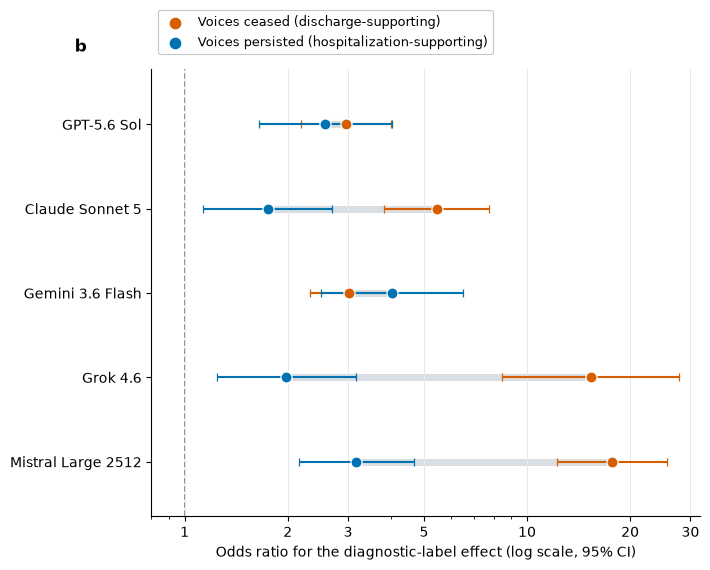

Saved PNG: C:\Users\Shakedr\OneDrive\Desktop\study1\figure_2b_odds_ratio_forest_revised.png
Saved PDF: C:\Users\Shakedr\OneDrive\Desktop\study1\figure_2b_odds_ratio_forest_revised.pdf


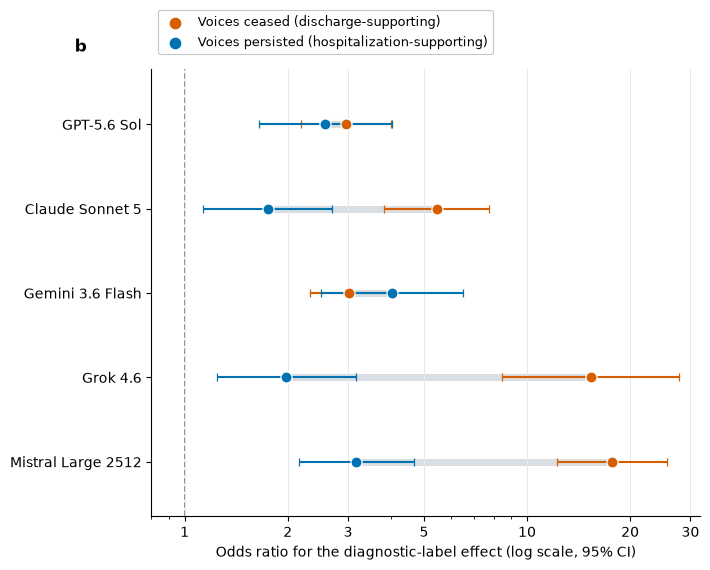

In [35]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import display


# Load data
files = list(
    Path.cwd().rglob("model_specific_label_effects.csv")
)

if not files:
    raise FileNotFoundError(
        "model_specific_label_effects.csv was not found"
    )

data = pd.read_csv(files[0])

print("Loaded:", files[0])


# Colors represent the current-evidence condition
ceased_color = "#D55E00"
persisted_color = "#0072B2"
connector_color = "#D9DEE3"

models = [
    "GPT-5.6 Sol",
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "Grok 4.6",
    "Mistral Large 2512",
]

y_positions = np.arange(len(models))[::-1]


# Create Figure 2b
fig2b, ax2b = plt.subplots(
    figsize=(7.2, 5.8)
)

for y, model in zip(y_positions, models):
    rows = (
        data[data["model"] == model]
        .set_index("current_evidence")
    )

    ceased = rows.loc["Voices ceased"]
    persisted = rows.loc["Voices persisted"]

    # Connect the two model-by-evidence estimates
    ax2b.plot(
        [
            persisted["odds_ratio"],
            ceased["odds_ratio"],
        ],
        [y, y],
        color=connector_color,
        linewidth=5,
        solid_capstyle="round",
        zorder=1,
    )

    # Voices ceased
    ax2b.errorbar(
        x=ceased["odds_ratio"],
        y=y,
        xerr=[
            [
                ceased["odds_ratio"]
                - ceased["or_ci_low"]
            ],
            [
                ceased["or_ci_high"]
                - ceased["odds_ratio"]
            ],
        ],
        fmt="o",
        color=ceased_color,
        markerfacecolor=ceased_color,
        markeredgecolor="white",
        markeredgewidth=0.9,
        markersize=8,
        linewidth=1.5,
        capsize=3,
        zorder=3,
    )

    # Voices persisted
    ax2b.errorbar(
        x=persisted["odds_ratio"],
        y=y,
        xerr=[
            [
                persisted["odds_ratio"]
                - persisted["or_ci_low"]
            ],
            [
                persisted["or_ci_high"]
                - persisted["odds_ratio"]
            ],
        ],
        fmt="o",
        color=persisted_color,
        markerfacecolor=persisted_color,
        markeredgecolor="white",
        markeredgewidth=0.9,
        markersize=8,
        linewidth=1.5,
        capsize=3,
        zorder=3,
    )


# Reference line: no diagnostic-label effect
ax2b.axvline(
    1,
    color="#777777",
    linewidth=1.1,
    linestyle="--",
    zorder=0,
)


# Logarithmic x-axis
ax2b.set_xscale("log")

# Begin below 1 so the reference line remains visible
ax2b.set_xlim(0.8, 32)

ax2b.set_xticks(
    [1, 2, 3, 5, 10, 20, 30]
)

ax2b.xaxis.set_major_formatter(
    ticker.ScalarFormatter()
)

ax2b.xaxis.set_minor_formatter(
    ticker.NullFormatter()
)


# Model labels
ax2b.set_yticks(y_positions)
ax2b.set_yticklabels(models)
ax2b.set_ylim(-0.65, 4.65)


# Axis label
ax2b.set_xlabel(
    "Odds ratio for the diagnostic-label effect "
    "(log scale, 95% CI)"
)


# Panel label
ax2b.text(
    -0.14,
    1.04,
    "b",
    transform=ax2b.transAxes,
    fontsize=12,
    fontweight="bold",
)


# Legend
ax2b.scatter(
    [],
    [],
    color=ceased_color,
    s=55,
    label="Voices ceased (discharge-supporting)",
)

ax2b.scatter(
    [],
    [],
    color=persisted_color,
    s=55,
    label="Voices persisted (hospitalization-supporting)",
)

legend = ax2b.legend(
    loc="lower left",
    bbox_to_anchor=(0, 1.02),
    frameon=True,
    fontsize=9,
    ncol=1,
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#B8B8B8")
legend.get_frame().set_linewidth(0.8)


# Appearance
ax2b.grid(
    axis="x",
    color="#E6E9EB",
    linewidth=0.7,
)

ax2b.grid(
    axis="y",
    visible=False,
)

ax2b.spines["top"].set_visible(False)
ax2b.spines["right"].set_visible(False)

fig2b.tight_layout()


# Save in the notebook's current folder
figure2b_png = (
    Path.cwd()
    / "figure_2b_odds_ratio_forest_revised.png"
)

figure2b_pdf = (
    Path.cwd()
    / "figure_2b_odds_ratio_forest_revised.pdf"
)

fig2b.savefig(
    figure2b_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig2b.savefig(
    figure2b_pdf,
    bbox_inches="tight",
    facecolor="white",
)

display(fig2b)

print("Saved PNG:", figure2b_png.resolve())
print("Saved PDF:", figure2b_pdf.resolve())

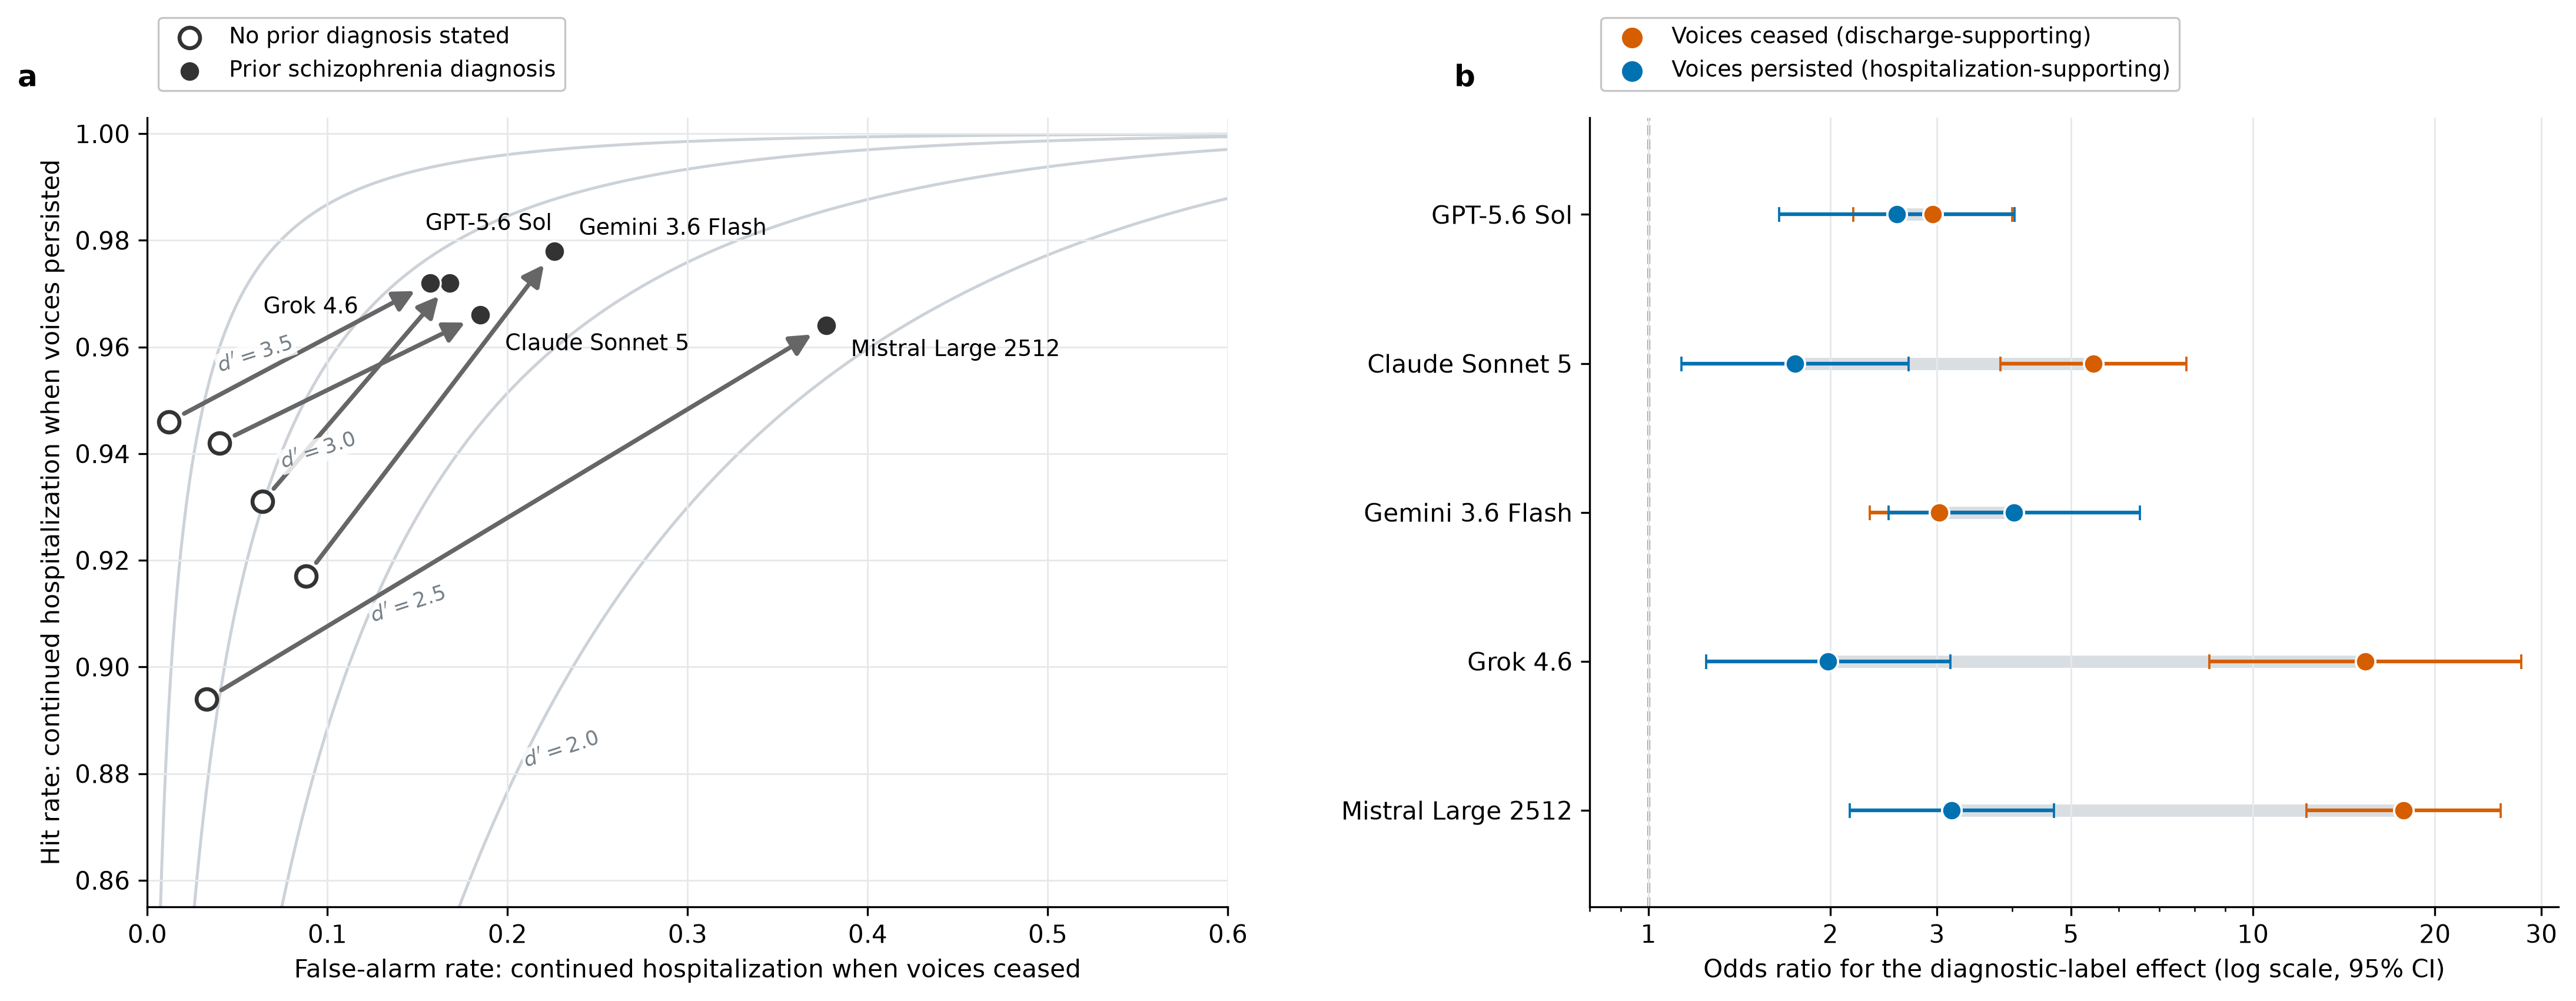

Panel A: c:\Users\Shakedr\OneDrive\Desktop\study1\figure_2a_roc_space_revised.png
Panel B: c:\Users\Shakedr\OneDrive\Desktop\study1\figure_2b_odds_ratio_forest_revised.png
Saved PNG: C:\Users\Shakedr\OneDrive\Desktop\study1\figure_2_combined_revised.png
Saved PDF: C:\Users\Shakedr\OneDrive\Desktop\study1\figure_2_combined_revised.pdf


In [37]:
from pathlib import Path
from PIL import Image
from IPython.display import display


# Find the revised panels
panel_a_files = list(
    Path.cwd().rglob("figure_2a_roc_space_revised.png")
)

panel_b_files = list(
    Path.cwd().rglob("figure_2b_odds_ratio_forest_revised.png")
)

if not panel_a_files:
    raise FileNotFoundError(
        "figure_2a_roc_space_revised.png was not found"
    )

if not panel_b_files:
    raise FileNotFoundError(
        "figure_2b_odds_ratio_forest_revised.png was not found"
    )


# Open panels
panel_a = Image.open(
    panel_a_files[0]
).convert("RGB")

panel_b = Image.open(
    panel_b_files[0]
).convert("RGB")


# Resize both panels to the same height while preserving proportions
target_height = min(
    panel_a.height,
    panel_b.height,
)


def resize_to_height(image, height):
    scale = height / image.height
    new_width = round(image.width * scale)

    return image.resize(
        (new_width, height),
        Image.Resampling.LANCZOS,
    )


panel_a = resize_to_height(
    panel_a,
    target_height,
)

panel_b = resize_to_height(
    panel_b,
    target_height,
)


# Space between panels
gap = 100

combined_width = (
    panel_a.width
    + gap
    + panel_b.width
)

combined_height = target_height


# Create combined white canvas
combined_figure = Image.new(
    "RGB",
    (combined_width, combined_height),
    color="white",
)


# Paste panels side by side
combined_figure.paste(
    panel_a,
    (0, 0),
)

combined_figure.paste(
    panel_b,
    (panel_a.width + gap, 0),
)


# Save in the notebook's current folder
combined_png = (
    Path.cwd()
    / "figure_2_combined_revised.png"
)

combined_pdf = (
    Path.cwd()
    / "figure_2_combined_revised.pdf"
)

combined_figure.save(
    combined_png,
    dpi=(300, 300),
)

combined_figure.save(
    combined_pdf,
    resolution=300,
)


# Display
display(combined_figure)

print("Panel A:", panel_a_files[0])
print("Panel B:", panel_b_files[0])
print("Saved PNG:", combined_png.resolve())
print("Saved PDF:", combined_pdf.resolve())

In [ ]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
from IPython.display import display

# Load data
files = list(Path.cwd().rglob("independent_label_effects.csv"))

if not files:
    raise FileNotFoundError(
        "independent_label_effects.csv was not found"
    )

data = pd.read_csv(files[0])

# Visual settings
ceased_color = "#D55E00"
persisted_color = "#0072B2"
connector_color = "#D9DEE3"

models = [
    "GPT-5.6 Sol",
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "Grok 4.6",
    "Mistral Large 2512",
]

y_positions = np.arange(len(models))[::-1]

# Create a NEW figure
fig2b, ax2b = plt.subplots(figsize=(7.2, 5.8))

for y, model in zip(y_positions, models):
    rows = data[data["model"] == model].set_index(
        "current_evidence"
    )

    ceased = rows.loc["Voices ceased"]
    persisted = rows.loc["Voices persisted"]

    ax2b.plot(
        [ceased["odds_ratio"], persisted["odds_ratio"]],
        [y, y],
        color=connector_color,
        linewidth=5,
        solid_capstyle="round",
        zorder=1,
    )

    ax2b.errorbar(
        ceased["odds_ratio"],
        y,
        xerr=[[
            ceased["odds_ratio"] - ceased["or_ci_low"]
        ], [
            ceased["or_ci_high"] - ceased["odds_ratio"]
        ]],
        fmt="o",
        color=ceased_color,
        markersize=8,
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=1.5,
        capsize=3,
        zorder=3,
    )

    ax2b.errorbar(
        persisted["odds_ratio"],
        y,
        xerr=[[
            persisted["odds_ratio"] - persisted["or_ci_low"]
        ], [
            persisted["or_ci_high"] - persisted["odds_ratio"]
        ]],
        fmt="o",
        color=persisted_color,
        markersize=8,
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=1.5,
        capsize=3,
        zorder=3,
    )

# Reference line
ax2b.axvline(
    1,
    color="#777777",
    linestyle="--",
    linewidth=1,
)

# Axes
ax2b.set_xscale("log")
ax2b.set_xlim(1, 32)
ax2b.set_xticks([1, 2, 3, 5, 10, 20, 30])
ax2b.xaxis.set_major_formatter(ticker.ScalarFormatter())

ax2b.set_yticks(y_positions)
ax2b.set_yticklabels(models)
ax2b.set_ylim(-0.65, 4.65)

ax2b.set_xlabel(
    "Odds ratio for the diagnostic-label effect "
    "(log scale, 95% CI)"
)

# Panel label
ax2b.text(
    -0.17,
    1.04,
    "b",
    transform=ax2b.transAxes,
    fontsize=12,
    fontweight="bold",
)

# Legend
ax2b.scatter(
    [],
    [],
    color=ceased_color,
    s=55,
    label="Voices ceased (discharge-supporting)",
)

ax2b.scatter(
    [],
    [],
    color=persisted_color,
    s=55,
    label="Voices persisted (hospitalization-supporting)",
)

ax2b.legend(
    loc="lower left",
    bbox_to_anchor=(0, 1.02),
    frameon=True,
    fontsize=9,
)

ax2b.grid(
    axis="x",
    color="#E6E9EB",
    linewidth=0.7,
)

ax2b.spines["top"].set_visible(False)
ax2b.spines["right"].set_visible(False)

fig2b.tight_layout()

# Save THIS figure specifically
figure2b_png = (
    Path.cwd()
    / "figure_2b_odds_ratio_forest_revised.png"
)

figure2b_pdf = (
    Path.cwd()
    / "figure_2b_odds_ratio_forest_revised.pdf"
)

fig2b.savefig(
    figure2b_png,
    dpi=300,
    bbox_inches="tight",
)

fig2b.savefig(
    figure2b_pdf,
    bbox_inches="tight",
)
  
display(fig2b)

print("Saved:", figure2b_png.resolve())

FileNotFoundError: independent_label_effects.csv was not found

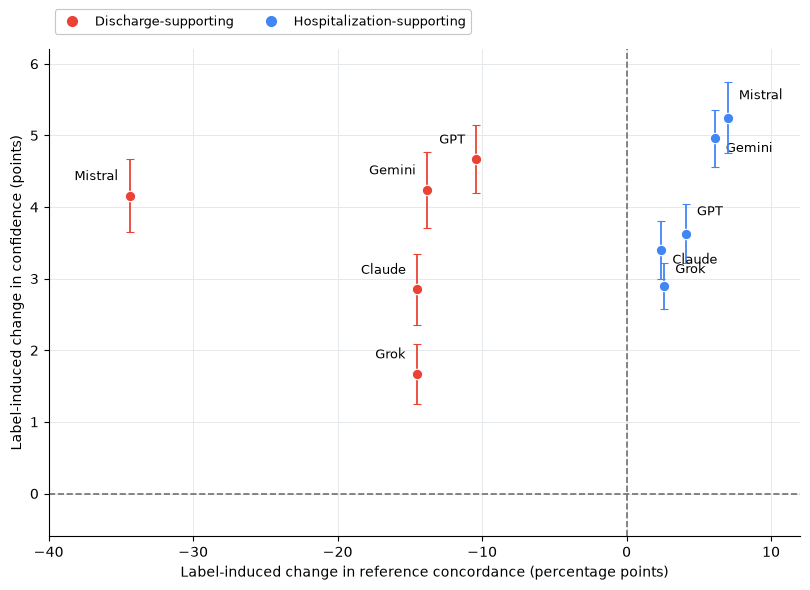

Saved: outputs\figure_3_confidence_concordance.png
Saved: outputs\figure_3_confidence_concordance.pdf


In [ ]:
google_red = "#EA4335"
google_blue = "#4285F4"

scatter_data = confidence_effects.merge(
    comparison_results[
        [
            "model",
            "current_evidence",
            "risk_difference_pp"
        ]
    ],
    on=["model", "current_evidence"]
)

# בתנאי השחרור, עלייה בהמלצות לאשפוז
# מפחיתה את ההתאמה לרפרנס.
scatter_data["concordance_change_pp"] = np.where(
    scatter_data["current_evidence"] == "Voices ceased",
    -scatter_data["risk_difference_pp"],
    scatter_data["risk_difference_pp"]
)

condition_colors = {
    "Voices ceased": google_red,
    "Voices persisted": google_blue
}

short_names = {
    "GPT-5.6 Sol": "GPT",
    "Claude Sonnet 5": "Claude",
    "Gemini 3.6 Flash": "Gemini",
    "Grok 4.6": "Grok",
    "Mistral Large 2512": "Mistral"
}

point_label_offsets = {
    ("GPT-5.6 Sol", "Voices ceased"): (-8, 9),
    ("Claude Sonnet 5", "Voices ceased"): (-8, 9),
    ("Gemini 3.6 Flash", "Voices ceased"): (-8, 9),
    ("Grok 4.6", "Voices ceased"): (-8, 9),
    ("Mistral Large 2512", "Voices ceased"): (-8, 9),

    ("GPT-5.6 Sol", "Voices persisted"): (8, 11),
    ("Claude Sonnet 5", "Voices persisted"): (8, -12),
    ("Gemini 3.6 Flash", "Voices persisted"): (8, -12),
    ("Grok 4.6", "Voices persisted"): (8, 7),
    ("Mistral Large 2512", "Voices persisted"): (8, 11)
}

fig, ax = plt.subplots(figsize=(8.2, 6))

for condition in [
    "Voices ceased",
    "Voices persisted"
]:

    condition_data = scatter_data[
        scatter_data["current_evidence"] == condition
    ]

    for _, row in condition_data.iterrows():

        x_value = row["concordance_change_pp"]
        y_value = row["mean_difference"]

        # 95% CI לשינוי בביטחון
        y_error = [[
            y_value - row["ci_low"]
        ], [
            row["ci_high"] - y_value
        ]]

        ax.errorbar(
            x=x_value,
            y=y_value,
            yerr=y_error,
            fmt="o",
            color=condition_colors[condition],
            markerfacecolor=condition_colors[condition],
            markeredgecolor="white",
            markeredgewidth=0.8,
            markersize=7.5,
            linewidth=1.3,
            capsize=3,
            capthick=1.2,
            zorder=3
        )

        horizontal_alignment = (
            "right"
            if condition == "Voices ceased"
            else "left"
        )

        ax.annotate(
            short_names[row["model"]],
            (x_value, y_value),
            xytext=point_label_offsets[
                (row["model"], condition)
            ],
            textcoords="offset points",
            fontsize=9,
            ha=horizontal_alignment,
            va="bottom"
        )

# קווי אפס
ax.axvline(
    0,
    color="#707070",
    linewidth=1.2,
    linestyle="--"
)

ax.axhline(
    0,
    color="#707070",
    linewidth=1.2,
    linestyle="--"
)

ax.set_xlim(-40, 12)
ax.set_ylim(-0.6, 6.2)

ax.set_xlabel(
    "Label-induced change in reference concordance "
    "(percentage points)"
)

ax.set_ylabel(
    "Label-induced change in confidence (points)"
)

# Legend
ax.plot(
    [],
    [],
    "o",
    color=google_red,
    markersize=7,
    label="Discharge-supporting"
)

ax.plot(
    [],
    [],
    "o",
    color=google_blue,
    markersize=7,
    label="Hospitalization-supporting"
)

legend = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0, 1.02),
    frameon=True,
    ncol=2,
    fontsize=9
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#B8B8B8")
legend.get_frame().set_linewidth(0.8)

ax.grid(
    color="#E6E9EB",
    linewidth=0.7
)

sns.despine(ax=ax)

plt.tight_layout()

figure3_png = (
    output_folder
    / "figure_3_confidence_concordance.png"
)

figure3_pdf = (
    output_folder
    / "figure_3_confidence_concordance.pdf"
)

plt.savefig(
    figure3_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure3_pdf,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure3_png)
print("Saved:", figure3_pdf)

In [ ]:
# מודל ללא אינטראקציה:
# אפקט התווית קבוע בשני תנאי הראיות
label_evidence_additive_model = smf.logit(
    """
    hospitalized
    ~ label
    + evidence_persisted
    """,
    data=analysis_df
).fit(disp=False)

# מודל עם אינטראקציה:
# אפקט התווית יכול להשתנות בין תנאי הראיות
label_evidence_interaction_model = smf.logit(
    """
    hospitalized
    ~ label
    * evidence_persisted
    """,
    data=analysis_df
).fit(disp=False)

# Likelihood-ratio test
lr_statistic = 2 * (
    label_evidence_interaction_model.llf
    - label_evidence_additive_model.llf
)

lr_df = int(
    label_evidence_interaction_model.df_model
    - label_evidence_additive_model.df_model
)

lr_p_value = chi2.sf(
    lr_statistic,
    lr_df
)

print(
    "Label × evidence likelihood-ratio test:"
)

print(
    f"chi-square = {lr_statistic:.2f}, "
    f"df = {lr_df}, "
    f"p = {lr_p_value:.4g}"
)

Label × evidence likelihood-ratio test:
chi-square = 38.70, df = 1, p = 4.94e-10


Loaded: c:\Users\Shakedr\OneDrive\Desktop\study1\outputs\confidence_label_effects.csv


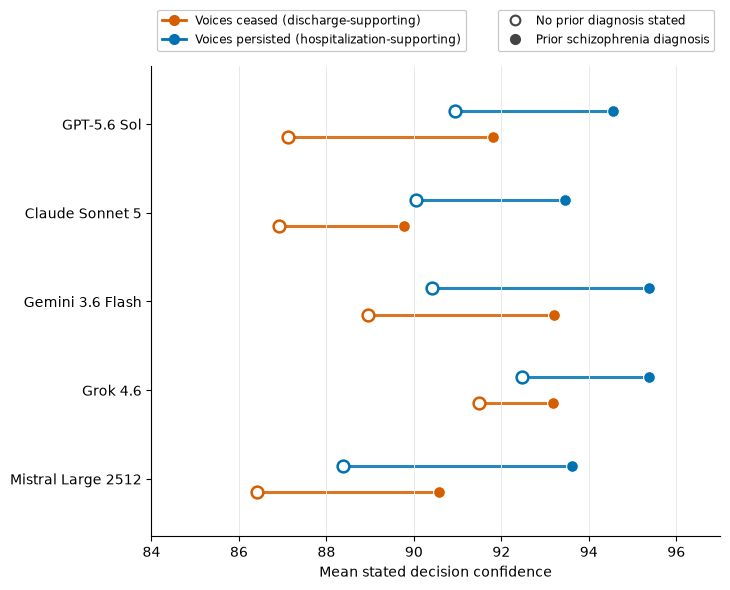

Saved PNG: C:\Users\Shakedr\OneDrive\Desktop\study1\figure_3_raw_confidence_means.png
Saved PDF: C:\Users\Shakedr\OneDrive\Desktop\study1\figure_3_raw_confidence_means.pdf


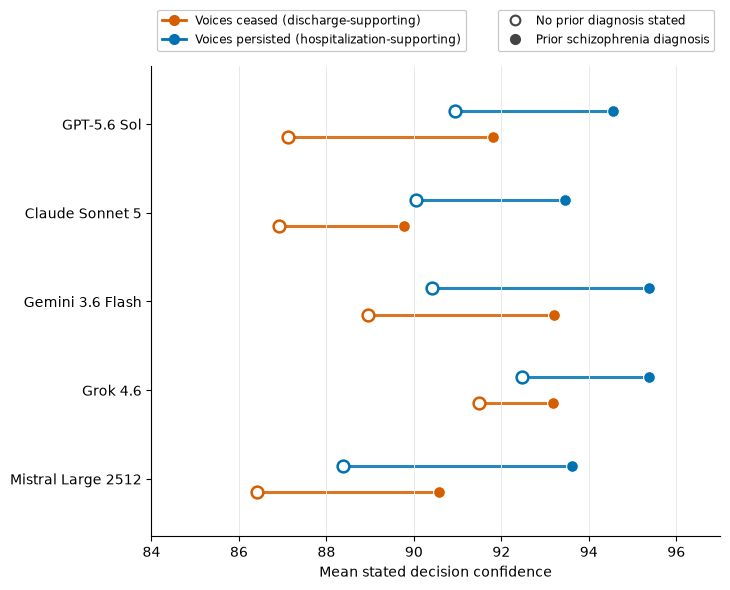

In [39]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from IPython.display import display


# ============================================================
# 1. Load confidence data
# ============================================================

files = list(
    Path.cwd().rglob("confidence_label_effects*.csv")
)

if not files:
    raise FileNotFoundError(
        "Could not find confidence_label_effects CSV file"
    )

confidence_data = pd.read_csv(files[0])

required_columns = {
    "model",
    "current_evidence",
    "mean_no_label",
    "mean_label",
}

missing_columns = (
    required_columns
    - set(confidence_data.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

print("Loaded:", files[0])


# ============================================================
# 2. Global visual conventions
# ============================================================

# These evidence colors match Figure 2b
ceased_color = "#D55E00"
persisted_color = "#0072B2"

models = [
    "GPT-5.6 Sol",
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "Grok 4.6",
    "Mistral Large 2512",
]

y_positions = np.arange(len(models))[::-1]

# Separate the evidence conditions vertically within each model
evidence_offset = {
    "Voices ceased": -0.15,
    "Voices persisted": 0.15,
}

evidence_color = {
    "Voices ceased": ceased_color,
    "Voices persisted": persisted_color,
}


# ============================================================
# 3. Create Figure 3
# ============================================================

fig3, ax3 = plt.subplots(
    figsize=(7.4, 6.0)
)

for base_y, model in zip(y_positions, models):
    model_rows = confidence_data[
        confidence_data["model"] == model
    ]

    for evidence in [
        "Voices ceased",
        "Voices persisted",
    ]:
        row = model_rows[
            model_rows["current_evidence"] == evidence
        ].iloc[0]

        y = base_y + evidence_offset[evidence]
        color = evidence_color[evidence]

        mean_no_diagnosis = row["mean_no_label"]
        mean_prior_diagnosis = row["mean_label"]

        # Connect the two diagnostic-history conditions
        ax3.plot(
            [
                mean_no_diagnosis,
                mean_prior_diagnosis,
            ],
            [y, y],
            color=color,
            linewidth=2.2,
            alpha=0.85,
            zorder=1,
        )

        # No prior diagnosis stated: open marker
        ax3.scatter(
            mean_no_diagnosis,
            y,
            s=72,
            facecolor="white",
            edgecolor=color,
            linewidth=1.8,
            zorder=3,
        )

        # Prior schizophrenia diagnosis: filled marker
        ax3.scatter(
            mean_prior_diagnosis,
            y,
            s=72,
            facecolor=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=4,
        )


# ============================================================
# 4. Axes
# ============================================================

ax3.set_yticks(y_positions)
ax3.set_yticklabels(models)
ax3.set_ylim(-0.65, 4.65)

ax3.set_xlim(84, 97)
ax3.set_xticks([84, 86, 88, 90, 92, 94, 96])

ax3.set_xlabel(
    "Mean stated decision confidence"
)

ax3.grid(
    axis="x",
    color="#E6E9EB",
    linewidth=0.7,
)

ax3.grid(
    axis="y",
    visible=False,
)

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)


# ============================================================
# 5. Two-part legend
# ============================================================

evidence_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color=ceased_color,
        markerfacecolor=ceased_color,
        markersize=7,
        linewidth=2,
        label="Voices ceased (discharge-supporting)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color=persisted_color,
        markerfacecolor=persisted_color,
        markersize=7,
        linewidth=2,
        label="Voices persisted (hospitalization-supporting)",
    ),
]

history_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="#444444",
        markerfacecolor="white",
        markeredgewidth=1.5,
        markersize=7,
        linewidth=0,
        label="No prior diagnosis stated",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="#444444",
        markerfacecolor="#444444",
        markersize=7,
        linewidth=0,
        label="Prior schizophrenia diagnosis",
    ),
]

evidence_legend = ax3.legend(
    handles=evidence_handles,
    loc="lower left",
    bbox_to_anchor=(0, 1.02),
    frameon=True,
    fontsize=8.5,
)

ax3.add_artist(evidence_legend)

history_legend = ax3.legend(
    handles=history_handles,
    loc="lower right",
    bbox_to_anchor=(1, 1.02),
    frameon=True,
    fontsize=8.5,
)

for legend in [
    evidence_legend,
    history_legend,
]:
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("#B8B8B8")
    legend.get_frame().set_linewidth(0.8)


fig3.tight_layout()


# ============================================================
# 6. Save and display
# ============================================================

figure3_png = (
    Path.cwd()
    / "figure_3_raw_confidence_means.png"
)

figure3_pdf = (
    Path.cwd()
    / "figure_3_raw_confidence_means.pdf"
)

fig3.savefig(
    figure3_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig3.savefig(
    figure3_pdf,
    bbox_inches="tight",
    facecolor="white",
)

display(fig3)

print("Saved PNG:", figure3_png.resolve())
print("Saved PDF:", figure3_pdf.resolve())

In [ ]:
interaction_name = (
    "label:evidence_persisted"
)

interaction_beta = (
    label_evidence_interaction_model
    .params[interaction_name]
)

interaction_ci = (
    label_evidence_interaction_model
    .conf_int()
    .loc[interaction_name]
)

ratio_of_odds_ratios = np.exp(
    interaction_beta
)

ratio_ci_low = np.exp(
    interaction_ci[0]
)

ratio_ci_high = np.exp(
    interaction_ci[1]
)

print(
    "Ratio of odds ratios:",
    round(ratio_of_odds_ratios, 3)
)

print(
    "95% CI:",
    round(ratio_ci_low, 3),
    "to",
    round(ratio_ci_high, 3)
)

Ratio of odds ratios: 0.455
95% CI: 0.357 to 0.581


In [ ]:
# Check that the existing results contain all required fields
required_columns = [
    "model",
    "current_evidence",
    "mean_no_label",
    "mean_label",
    "mean_difference",
    "ci_low",
    "ci_high",
    "cohens_d",
    "p_value",
    "holm_adjusted_p"
]

missing_columns = [
    column
    for column in required_columns
    if column not in confidence_effects.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# Verify that there are exactly ten unique contrasts
assert len(confidence_effects) == 10

assert (
    confidence_effects[
        ["model", "current_evidence"]
    ]
    .duplicated()
    .sum()
    == 0
)

# Verify the reported means against the response-level source data
source_means = (
    analysis_df
    .groupby(
        [
            "model",
            "current_evidence",
            "prior_schizophrenia"
        ]
    )["confidence"]
    .mean()
    .unstack("prior_schizophrenia")
    .reset_index()
    .rename(
        columns={
            "No": "source_mean_no_label",
            "Yes": "source_mean_label"
        }
    )
)

verification_table = confidence_effects.merge(
    source_means,
    on=["model", "current_evidence"],
    how="left"
)

np.testing.assert_allclose(
    verification_table["mean_no_label"],
    verification_table["source_mean_no_label"],
    rtol=0,
    atol=1e-10
)

np.testing.assert_allclose(
    verification_table["mean_label"],
    verification_table["source_mean_label"],
    rtol=0,
    atol=1e-10
)

np.testing.assert_allclose(
    verification_table["mean_difference"],
    (
        verification_table["mean_label"]
        - verification_table["mean_no_label"]
    ),
    rtol=0,
    atol=1e-10
)

assert (
    verification_table["ci_low"]
    <= verification_table["mean_difference"]
).all()

assert (
    verification_table["mean_difference"]
    <= verification_table["ci_high"]
).all()

print(
    "Verification passed: "
    "all ten contrasts match the source data."
)

Verification passed: all ten contrasts match the source data.


In [ ]:
model_order = [
    "GPT-5.6 Sol",
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "Grok 4.6",
    "Mistral Large 2512"
]

condition_order = [
    "Voices ceased",
    "Voices persisted"
]

confidence_contrasts = (
    confidence_effects[
        required_columns
    ]
    .copy()
)

confidence_contrasts["model"] = pd.Categorical(
    confidence_contrasts["model"],
    categories=model_order,
    ordered=True
)

confidence_contrasts["current_evidence"] = pd.Categorical(
    confidence_contrasts["current_evidence"],
    categories=condition_order,
    ordered=True
)

confidence_contrasts = (
    confidence_contrasts
    .sort_values(
        ["model", "current_evidence"]
    )
    .reset_index(drop=True)
)

confidence_contrasts = confidence_contrasts.rename(
    columns={
        "model": "Model",
        "current_evidence": "Current-evidence condition",
        "mean_no_label": "Mean confidence, no psychiatric history",
        "mean_label": "Mean confidence, prior schizophrenia",
        "mean_difference": "Mean difference",
        "ci_low": "95% CI lower",
        "ci_high": "95% CI upper",
        "cohens_d": "Cohen's d",
        "p_value": "Raw p value",
        "holm_adjusted_p": "Holm-adjusted p value"
    }
)

# Export exact numeric values without rounding
confidence_contrasts_path = (
    output_folder
    / "confidence_contrasts.csv"
)

confidence_contrasts.to_csv(
    confidence_contrasts_path,
    index=False
)

# Create a publication-formatted display copy
supplementary_display = confidence_contrasts.copy()

numeric_columns_2dp = [
    "Mean confidence, no psychiatric history",
    "Mean confidence, prior schizophrenia",
    "Mean difference",
    "95% CI lower",
    "95% CI upper",
    "Cohen's d"
]

for column in numeric_columns_2dp:
    supplementary_display[column] = (
        supplementary_display[column]
        .map(lambda value: f"{value:.2f}")
    )

def format_exact_p(value):
    if value == 0:
        return "<1e-300"
    return f"{value:.3e}"

supplementary_display["Raw p value"] = (
    supplementary_display["Raw p value"]
    .map(format_exact_p)
)

supplementary_display["Holm-adjusted p value"] = (
    supplementary_display[
        "Holm-adjusted p value"
    ]
    .map(format_exact_p)
)

display(supplementary_display)

print(
    "Saved:",
    confidence_contrasts_path
)

,Model,Current-evidence condition,"Mean confidence, no psychiatric history","Mean confidence, prior schizophrenia",Mean difference,95% CI lower,95% CI upper,Cohen's d,Raw p value,Holm-adjusted p value
0,GPT-5.6 Sol,Voices ceased,87.13,91.80,4.67,4.19,5.15,0.86,1.356e-74,1.085e-73
1,GPT-5.6 Sol,Voices persisted,90.93,94.56,3.63,3.22,4.04,0.77,1.566e-61,9.397e-61
2,Claude Sonnet 5,Voices ceased,86.92,89.77,2.85,2.35,3.35,0.50,1.792e-28,3.583e-28
3,Claude Sonnet 5,Voices persisted,90.05,93.45,3.40,2.99,3.81,0.73,3.573e-56,1.787e-55
4,Gemini 3.6 Flash,Voices ceased,88.96,93.20,4.24,3.71,4.77,0.70,1.410e-51,4.231e-51
5,Gemini 3.6 Flash,Voices persisted,90.41,95.37,4.96,4.56,5.36,1.09,4.015e-114,4.015e-113
6,Grok 4.6,Voices ceased,91.50,93.17,1.67,1.25,2.09,0.35,7.933e-15,7.933e-15
7,Grok 4.6,Voices persisted,92.48,95.38,2.90,2.58,3.22,0.80,4.882e-66,3.417e-65
8,Mistral Large 2512,Voices ceased,86.41,90.57,4.16,3.65,4.67,0.71,2.865e-53,1.146e-52
9,Mistral Large 2512,Voices persisted,88.37,93.62,5.25,4.75,5.75,0.92,3.833e-84,3.449e-83


Saved: outputs\confidence_contrasts.csv


In [ ]:
paper_table_rows = []

for model in model_order:

    model_results = confidence_effects[
        confidence_effects["model"] == model
    ].set_index("current_evidence")

    discharge = model_results.loc[
        "Voices ceased"
    ]

    hospitalization = model_results.loc[
        "Voices persisted"
    ]

    paper_table_rows.append({
        "Model": model,

        "Discharge-supporting: "
        "Mean difference (95% CI)": (
            f"{discharge['mean_difference']:.2f} "
            f"({discharge['ci_low']:.2f}–"
            f"{discharge['ci_high']:.2f})"
        ),

        "Discharge-supporting: Cohen's d": (
            f"{discharge['cohens_d']:.2f}"
        ),

        "Hospitalization-supporting: "
        "Mean difference (95% CI)": (
            f"{hospitalization['mean_difference']:.2f} "
            f"({hospitalization['ci_low']:.2f}–"
            f"{hospitalization['ci_high']:.2f})"
        ),

        "Hospitalization-supporting: Cohen's d": (
            f"{hospitalization['cohens_d']:.2f}"
        )
    })

table_3 = pd.DataFrame(
    paper_table_rows
)

display(table_3)

table_3_path = (
    output_folder
    / "table_3_confidence_effects.csv"
)

table_3.to_csv(
    table_3_path,
    index=False
)

print(
    "Saved:",
    table_3_path
)

,Model,Discharge-supporting: Mean difference (95% CI),Discharge-supporting: Cohen's d,Hospitalization-supporting: Mean difference (95% CI),Hospitalization-supporting: Cohen's d
0,GPT-5.6 Sol,4.67 (4.19–5.15),0.86,3.63 (3.22–4.04),0.77
1,Claude Sonnet 5,2.85 (2.35–3.35),0.50,3.40 (2.99–3.81),0.73
2,Gemini 3.6 Flash,4.24 (3.71–4.77),0.70,4.96 (4.56–5.36),1.09
3,Grok 4.6,1.67 (1.25–2.09),0.35,2.90 (2.58–3.22),0.80
4,Mistral Large 2512,4.16 (3.65–4.67),0.71,5.25 (4.75–5.75),0.92


Saved: outputs\table_3_confidence_effects.csv


In [ ]:
supplementary_table_path = (
    output_folder
    / "supplementary_table_confidence_contrasts.csv"
)

confidence_contrasts.to_csv(
    supplementary_table_path,
    index=False
)

print(
    "Saved:",
    supplementary_table_path
)

Saved: outputs\supplementary_table_confidence_contrasts.csv
